# Braincancer in *silico* modelling - the road map ahead

Christos Panagiotis Papanikas, Eleftheria Tzamali, Dimitris M. Manias, Eleftherios Ioannou, Dimitra Flouri, Soheil Soltani, Vangelis Sakkalis, Haralampos Hatzikirou and Vasileios Vavourakis.

**Python code for the cluster analysis**
V1.0.0, 28-04-2026<br>
****



In [32]:
# import sys
# !{sys.executable} -m pip install umap-learn

In [1]:
import os
import sys
sys.dont_write_bytecode = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import umap
import plotly.graph_objects as go
import cancer_dataset_module as module

data_dir = 'datasets'
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# Set if you want to include AI papers
include_AI = True

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

module.set_plot_style(font_size=18)


---
# Classification on clusters

In [2]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

## Set Dataset

In [3]:
data_org = module.load_dataset(data_dir)


#### Split to 4-5-year windows

In [4]:
year_ranges = module.YEAR_RANGES
data_org = module.add_opacity_columns(data_org, year_ranges)


#### Split to datasets of Mathematical Methods

In [5]:
split_datasets   = module.split_datasets_by_method(data_org)
data_ODEs              = split_datasets['ODEs']
data_PDEs              = split_datasets['PDEs']
data_Agent_based       = split_datasets['Agent_based']
data_Hybrid_Multiscale = split_datasets['Hybrid_Multiscale']
data_ML_AI             = split_datasets['ML_AI']


### Select Dataset for cluster analysis

In [6]:
################### Select full dataset or from mathematical methods ######################
data = data_org.copy()
# data = data_ODEs.copy()
# data = data_PDEs.copy()
# data = data_Agent_based.copy()
# data = data_Hybrid_Multiscale.copy()
# data = data_ML_AI.copy()

# data_2000_2004 = data[(data['Year'] >= 2000) & (data['Year'] <= 2004)].reset_index(drop=True)
# data_2005_2009 = data[(data['Year'] >= 2005) & (data['Year'] <= 2009)].reset_index(drop=True)
# data_2010_2013 = data[(data['Year'] >= 2010) & (data['Year'] <= 2013)].reset_index(drop=True)
# data_2014_2017 = data[(data['Year'] >= 2014) & (data['Year'] <= 2017)].reset_index(drop=True)
# data_2018_2021 = data[(data['Year'] >= 2018) & (data['Year'] <= 2021)].reset_index(drop=True)
# data_2022_2025 = data[(data['Year'] >= 2022) & (data['Year'] <= 2025)].reset_index(drop=True)

####################### Select full dataset or from year range ###########################
#data = data_2000_2004.copy()
#data = data_2005_2009.copy()
#data = data_2010_2013.copy()
#data = data_2014_2017.copy()
#data = data_2018_2021.copy()
#data = data_2022_2025s.copy()
print(data.shape[0], 'publications have been selected')

568 publications have been selected


----
# Histograms

In [7]:
percentage = False

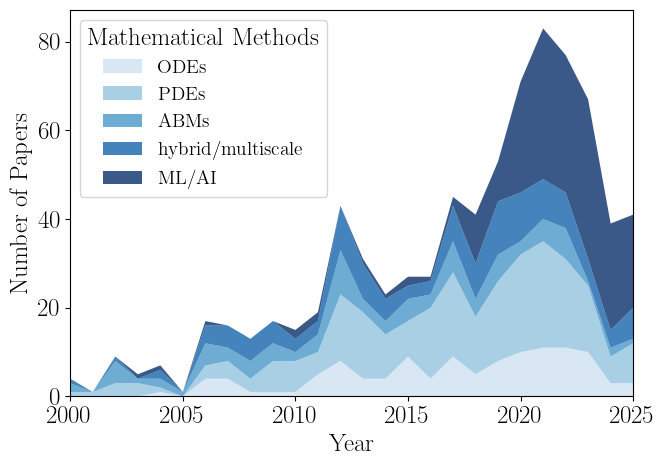

In [8]:
methods_per_year = module.plot_methods_streamgraph(data, output_dir, percentage=percentage)


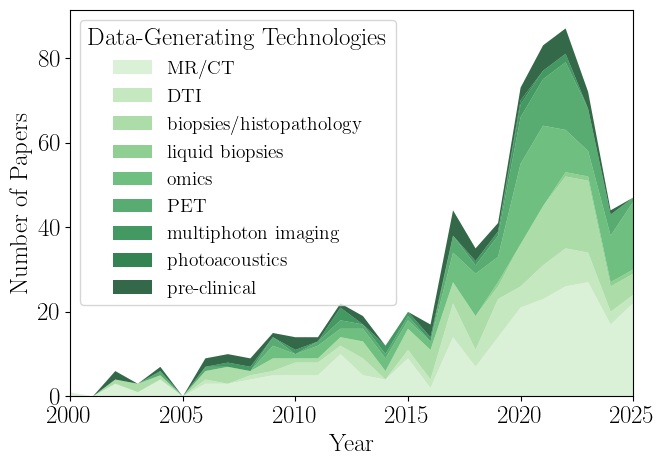

In [9]:
data_tech_per_year = module.plot_data_technologies_streamgraph(data, output_dir, percentage=percentage)


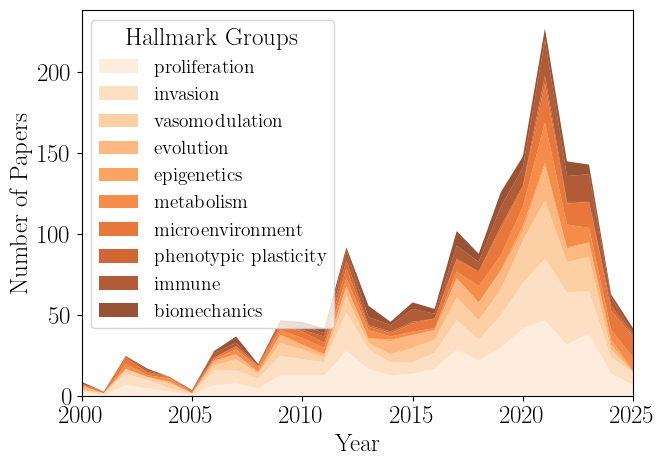

In [10]:
hallmark_group_per_year = module.plot_hallmark_groups_streamgraph(data, output_dir, percentage=percentage)


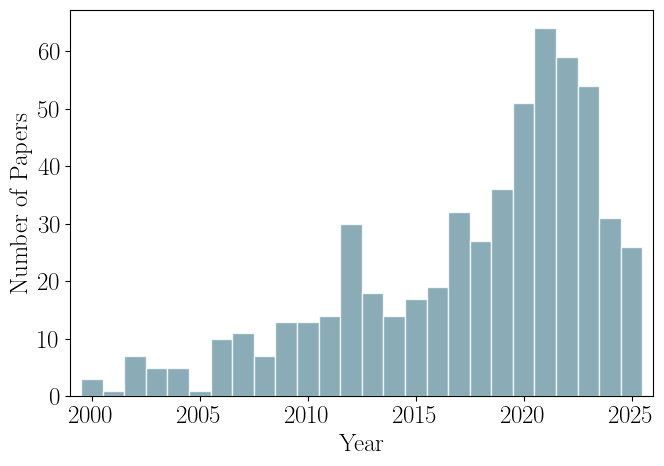

In [11]:
total_papers_per_year = module.plot_total_papers_histogram(data, output_dir, percentage=percentage)


### Choose features from original dataset

In [12]:
############################ Choose what features will be used to UMAP ###########################
# Edit module.ALL_FEATURES (in cancer_dataset_module.py) to change which columns are used,
# or pass a custom list as the second argument to prepare_features_for_umap below.
features = module.ALL_FEATURES.copy()

X, X_scaled, data_scaled, data_scaled_for_Umap, data_for_Umap = module.prepare_features_for_umap(data, features)


----
### Cluster on UMAP features

In [13]:
###### Manually adjust min_dist, n_components and random_state ##################
###### to create initial UMAP on which clustering will be conducted #############
data, features, X, X_scaled, data_scaled = module.compute_umap_embedding(
    data, data_for_Umap, n_neighbors=30, min_dist=0.01, n_components=3, random_state=42
)


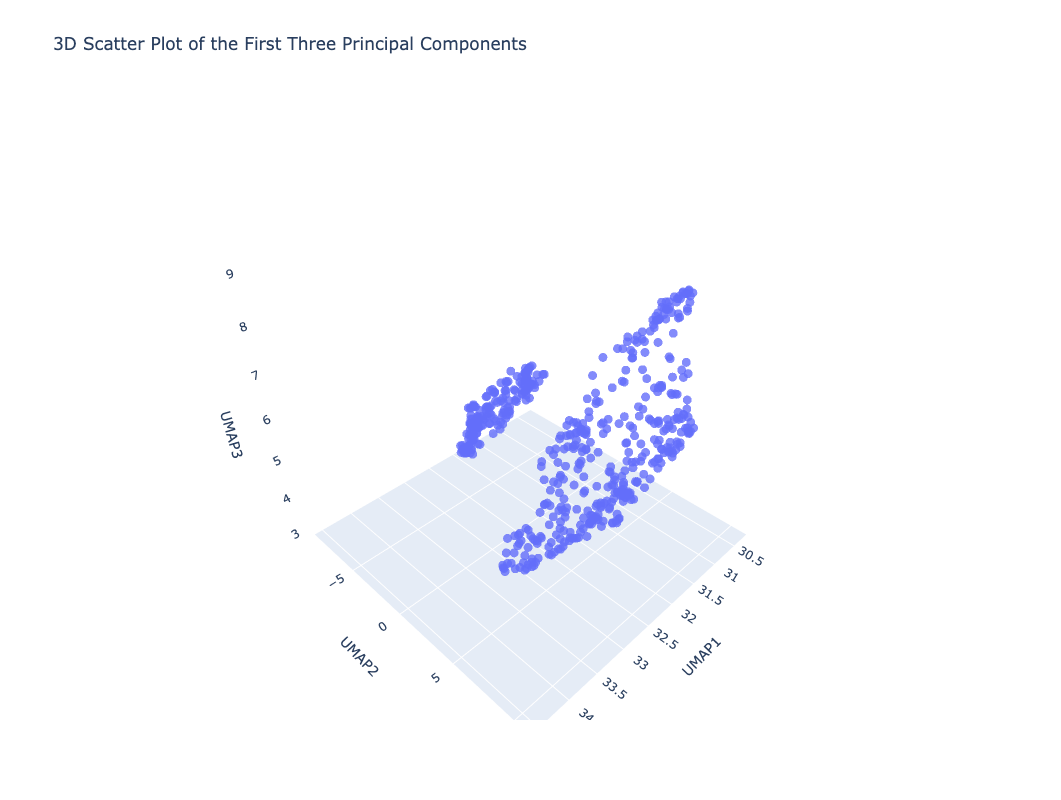

In [14]:
fig = module.plot_umap_3d_scatter(data)


## K-means

In [15]:
############# Manually change k to check what number of clusters returns ###########
############# highest silhouette score using K-means ###############################

k = 4
data, cluster_means, sil_score = module.run_kmeans_clustering(data, X_scaled, features, k=k, random_state=42)


Silhouette Score: 0.563


## Gaussian Mixture Models (GMM) 

In [16]:
######### Manually change n_components to check what number of clusters returns #####
######### highest silhouette score using GMM ########################################

n_components = 4
data, sil_score = module.run_gmm_clustering(data, X_scaled, n_components=n_components, random_state=42)


Silhouette Score: 0.413


In [17]:
data = module.finalize_cluster_labels(data)


## UMAP on clusters - Uncomment to check

In [22]:
# module.plot_umap_clusters(data_scaled=data_scaled, data_original=data, output_dir=output_dir, n_neighbors=80, min_dist=1,type='Kmeans')

In [19]:
# module.plot_umap_clusters(data_scaled=data_scaled, data_original=data, output_dir=output_dir, n_neighbors=80, min_dist=1, type='GMM')

----
## Feature Importance

In [19]:
#################### Choose what features will be investigated ########################

features = module.get_feature_importance_features(include_AI)
X = data[features]


All cluster feature importance plots have been saved to "figures"


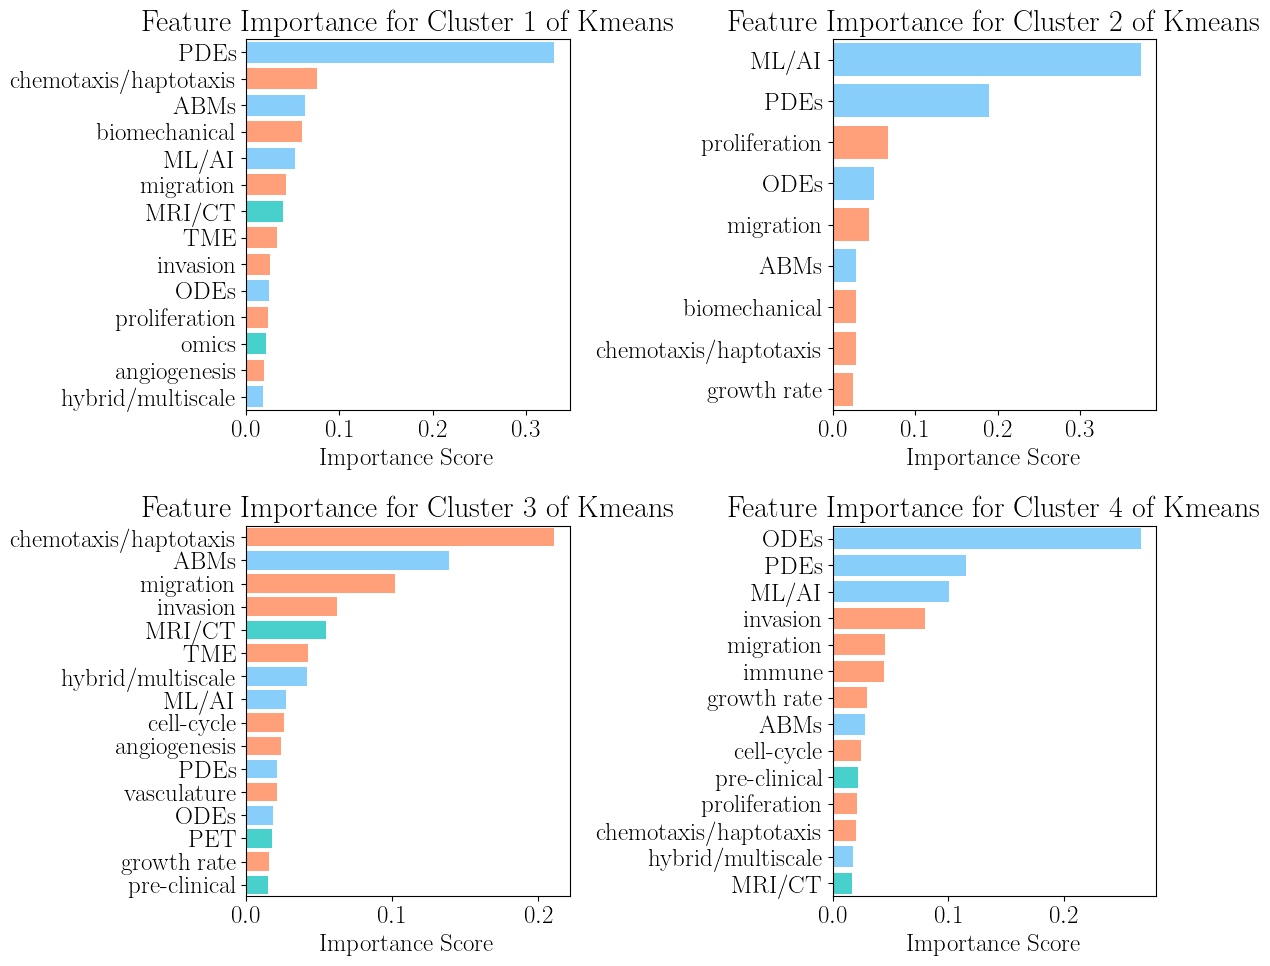

In [20]:
####### Set manually which method's clusters will be analysed ######
method='Kmeans'
# method='GMM'

y = data[f'{method}_Cluster']

######## Saves figures in output_dir/ and prints on screen - Manually change target_percentage(s) #######
cluster_feature_importances = module.analyze_cluster_feature_importance(
    X, y, method, output_dir,
    save_target_percentage=0.99, save_top=20,
    plot_target_percentage=0.84, plot_columns=2
)


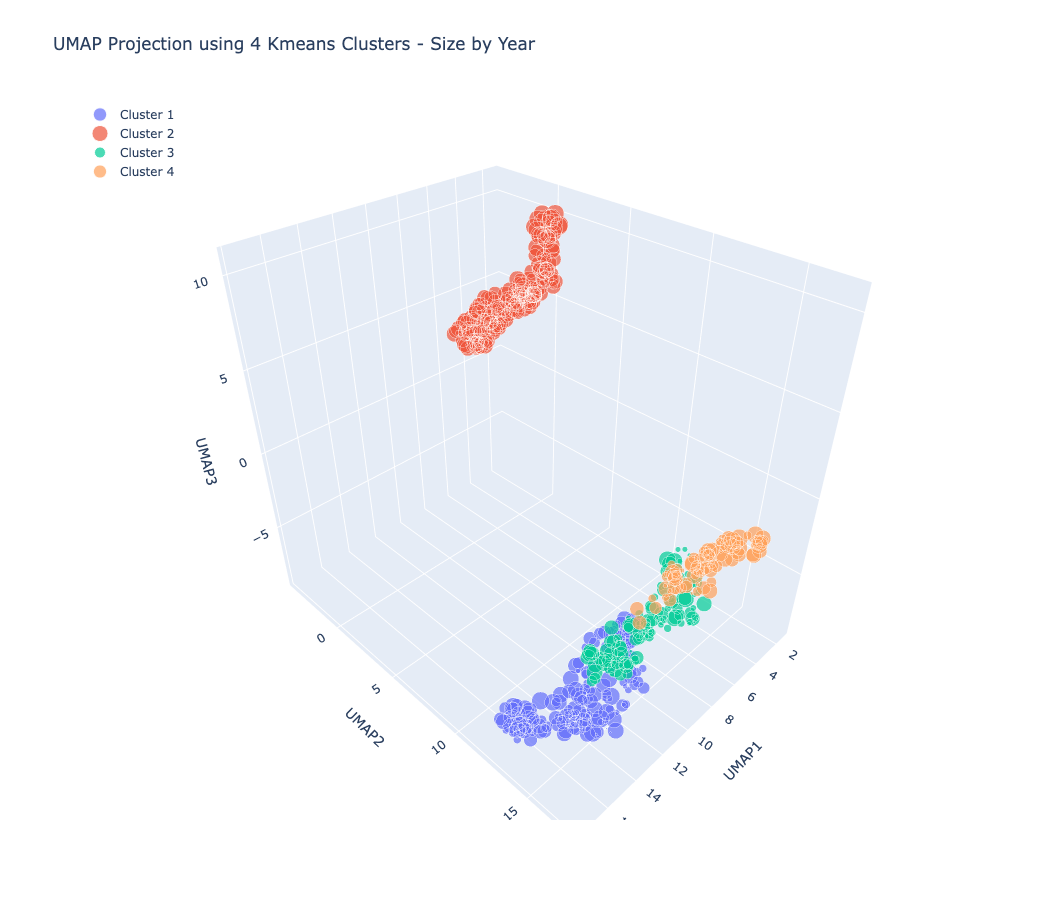

Plot saved to figures/UMAP_Kmeans_Clusters.html


In [21]:
module.plot_umap_clusters(data_scaled=data_scaled, data_original=data, output_dir=output_dir, n_neighbors=80, min_dist=1, type=method)

---
# Cluster summarized information

In [23]:
# Determine which variable to use for the naming/loop
cluster_count = k if method == "Kmeans" else n_components
save_path = module.save_publication_lists_by_cluster(data, method, cluster_count, data_dir)


The publication lists per cluster were saved in datasets/publication_lists_of_4_Kmeans_clusters


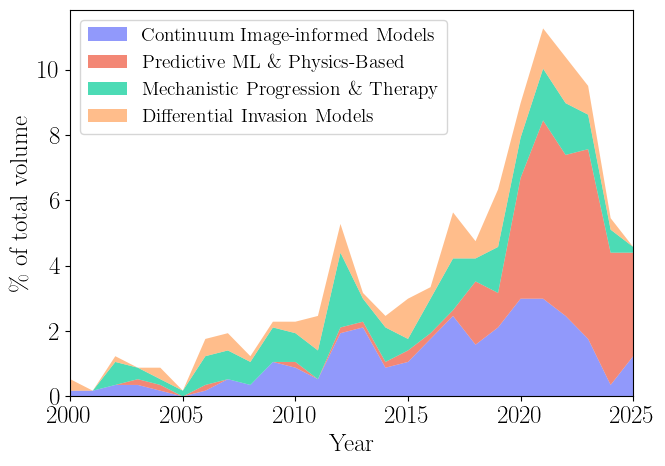

In [24]:
percentage = True
cluster_counts_per_year_updated = module.plot_cluster_streamgraph_by_year(data, method, output_dir, percentage=percentage)


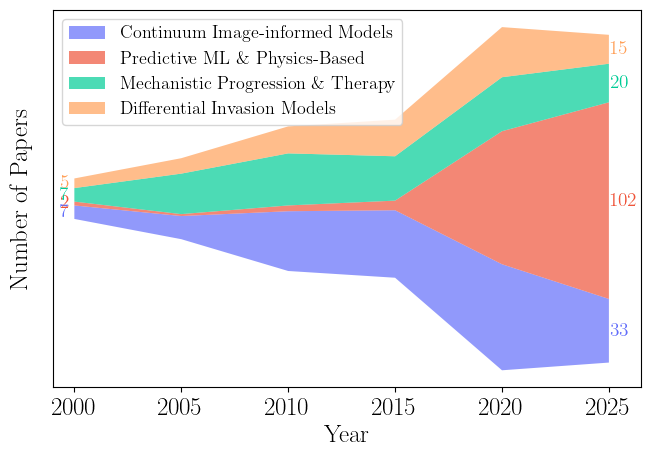

In [25]:
# A) Basic Parameters
percentage = False

cluster_counts_per_window = module.plot_cluster_streamgraph_5yr_windows(data, method, output_dir, percentage=percentage)


In [26]:
data.to_csv(f'{data_dir}/Main_Dataset_clustered.csv')

----
# Cluster projection on MM-DT-HlM based on multiclass classification

In [27]:
dataset = data.copy()

In [28]:
math_methods, data_technologies, hallmarks, rest = module.get_classification_feature_groups(include_AI)


In [29]:
# Classify Mathematical Methods, Data Technologies and Hallmarks (one probability per publication per group)
probabilities_df, final_dataset = module.classify_group_probabilities(dataset, math_methods, data_technologies, hallmarks, rest)


In [30]:
math_probs_df, data_tech_probs_df, hallmarks_probs_df = module.classify_group_weighted_scores(
    dataset, math_methods, data_technologies, hallmarks, rest
)


In [31]:
dataset = module.compute_mm_dt_hm_scores(
    dataset, math_methods, data_technologies, hallmarks,
    math_probs_df, data_tech_probs_df, hallmarks_probs_df
)


In [32]:
# dataset.head(1)

In [33]:
# Group by the '{method}_Cluster' and calculate the mean for 'MM', 'DT', and 'Hm'
cluster_centers = dataset.groupby(f'{method}_Cluster')[['MM', 'DT', 'Hm']].mean()

In [34]:
## Uncomment for interactive clusters/centers

# module.plot_clustered_probabilities_with_centers(
#     data=dataset, prob_cols=['MM', 'DT', 'Hm'], 
#     output_dir=output_dir, cluster_col=f"{method}_Cluster"
# )

In [35]:
dataset.to_csv(f'{data_dir}/Main_Dataset_clustered.csv')

---
# Distribution of Cluster on each of the 'MM', 'DT' and 'Hm' axis

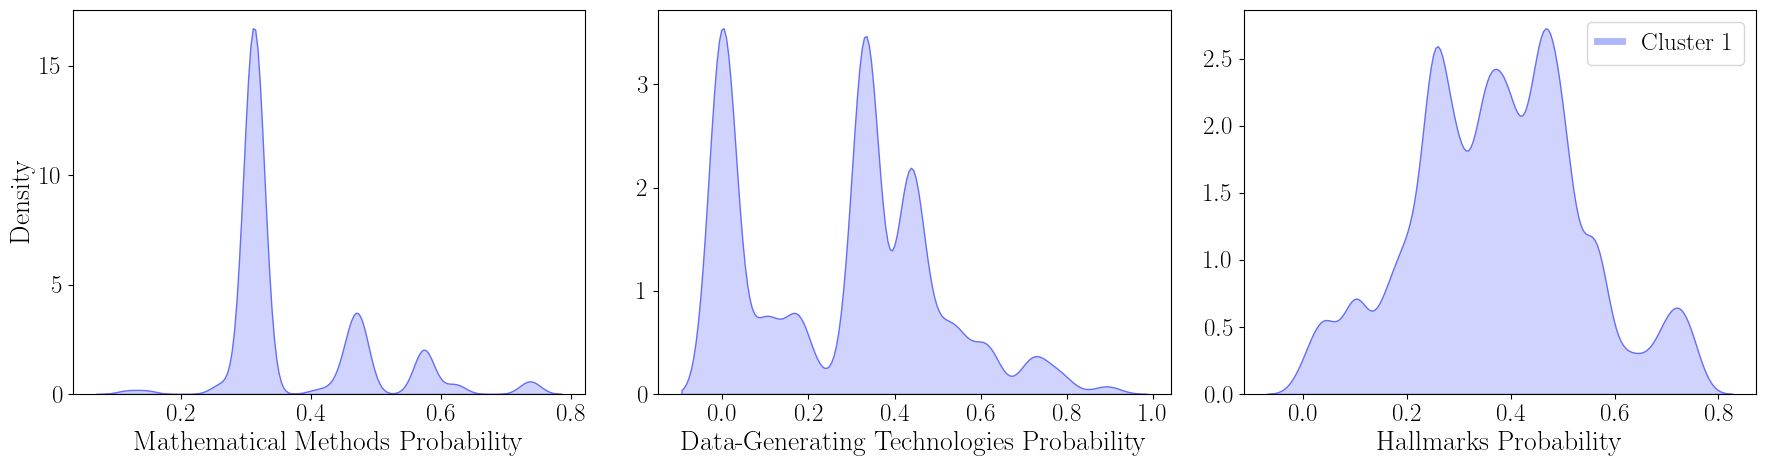

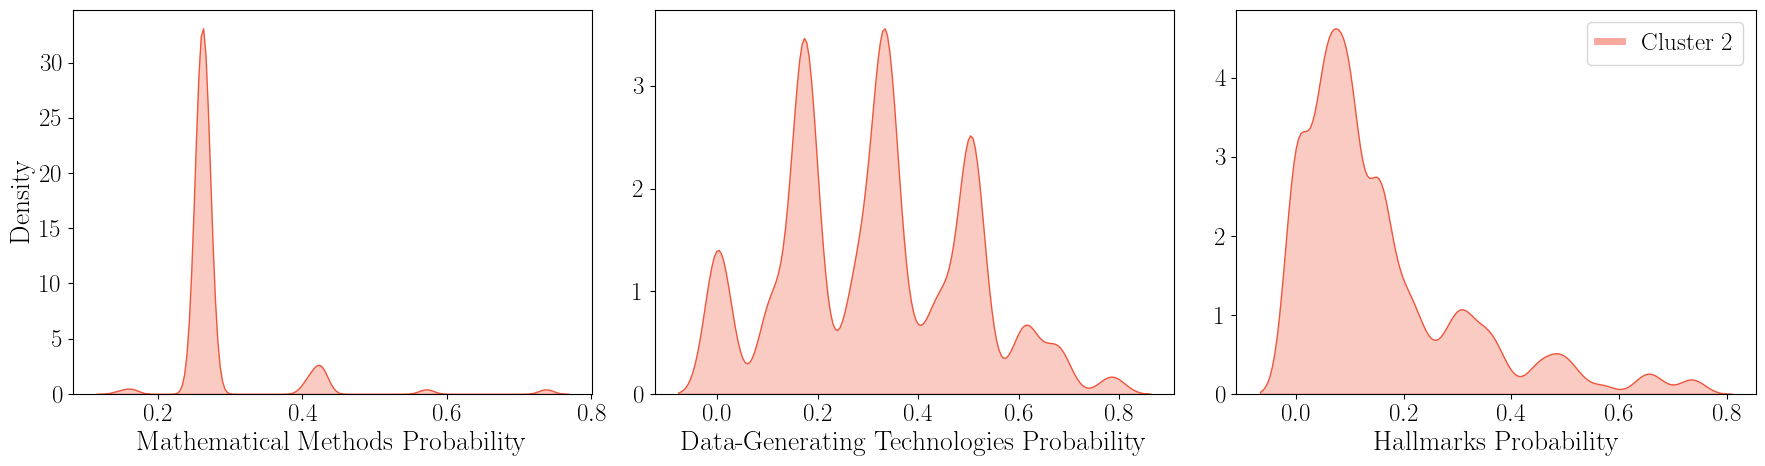

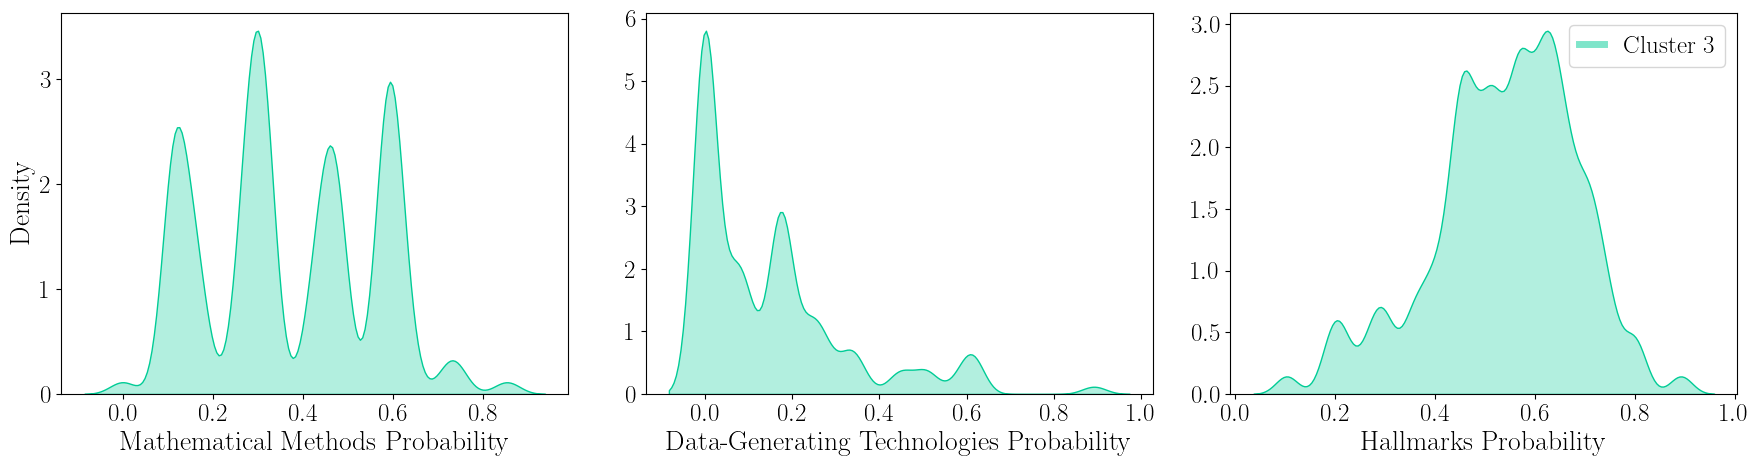

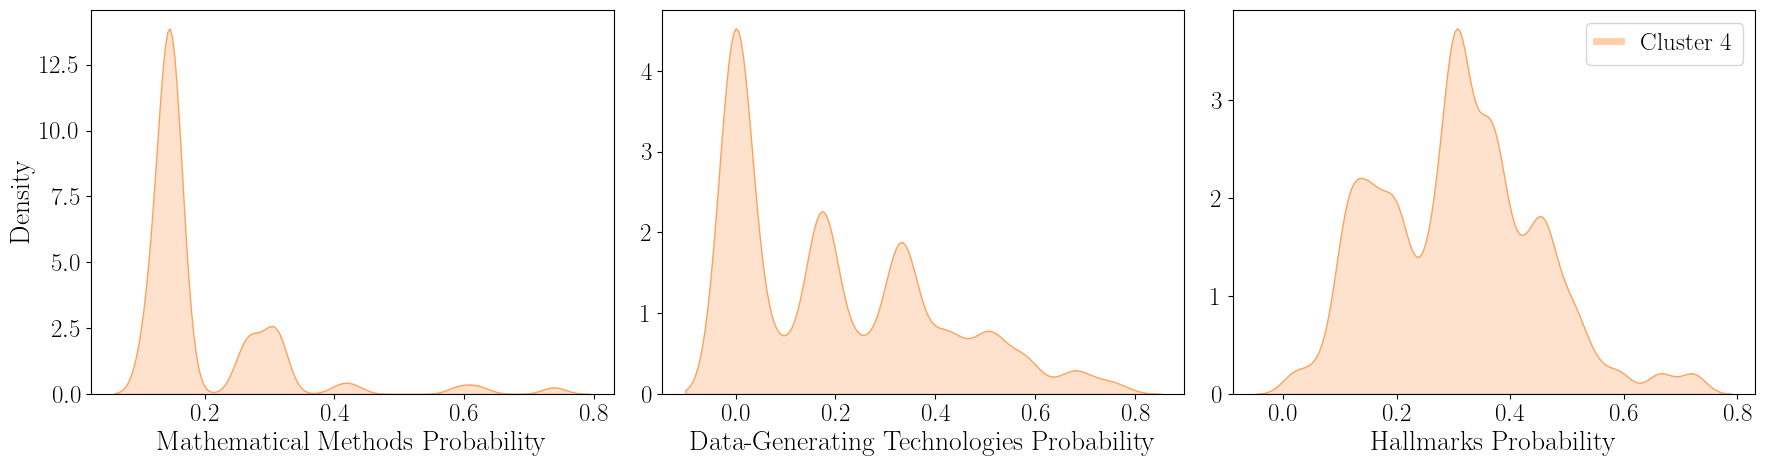

In [36]:
for i in range(1, cluster_count + 1):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    module.plot_cluster_distribution_sns(dataset, method, i, axes)
    plt.tight_layout()
    plt.show()

----
# Evolution of Cluster's Center in yearly windows with distributions planes

In [37]:
import cancer_dataset_module as module

%load_ext autoreload

In [38]:
autoreload 2

In [39]:
data['Year_Range'] = data['Year'].apply(module.assign_year_range)
dataset['Year_Range'] = dataset['Year'].apply(module.assign_year_range)


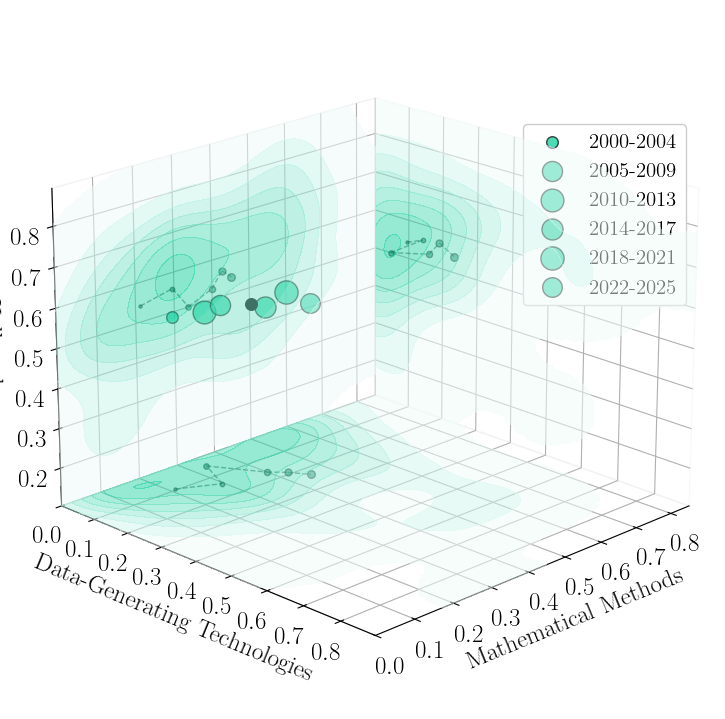

In [45]:
# Change manually for each cluster
clst = 3
module.plot_3d_with_range_centers(
    dataset, method, clst, cluster_centers,
    module.calculate_cluster_centers_by_range(dataset, method),
    output_dir=output_dir
);


----
# Evolution of Cluster's Center in yearly windows with distributions planes - Full dataset - Projections

In [46]:
dataset = module.compute_mm_dt_hm_scores(
    dataset, math_methods, data_technologies, hallmarks,
    math_probs_df, data_tech_probs_df, hallmarks_probs_df
)


In [47]:
# Arrow3D helper class and the overall-centers 3D trajectory plotting functions
# (calculate_overall_centers_by_range, calculate_2d_kde, darken_color,
# plot_overall_centers_with_projections) now live in cancer_dataset_module.py


In [48]:
if not include_AI:
    dataset = filtered_dataset = dataset[dataset['label_ML_AI'] != 1]
# Calculate overall centers and plot
overall_centers = module.calculate_overall_centers_by_range(dataset)


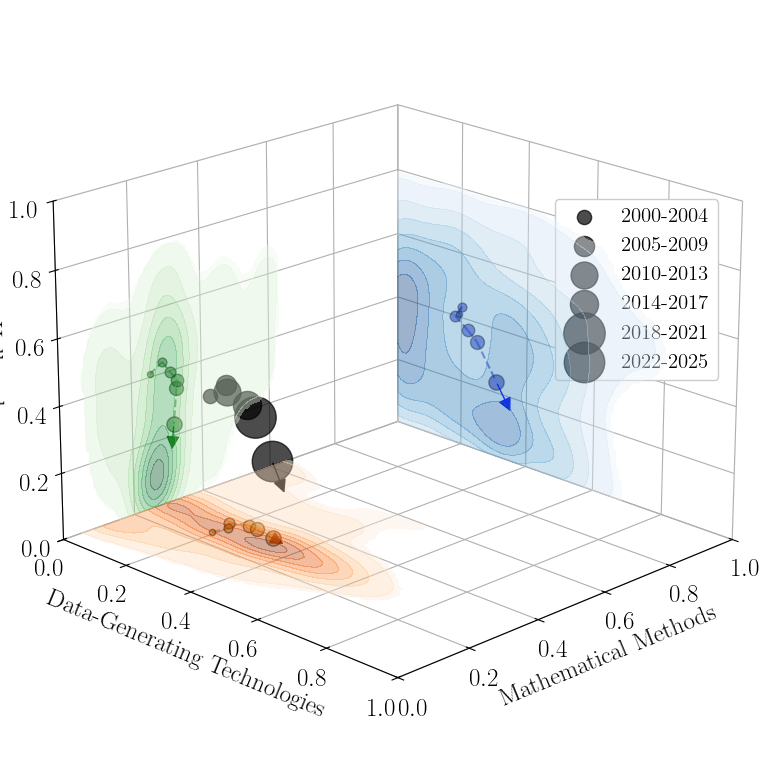

In [50]:
fig = module.plot_overall_centers_with_projections(
    dataset, overall_centers, output_dir, include_AI,
    filename_prefix='3D_Probability_Density_of_full_dataset_with_trajectories'
)


---
## Add unity weight in non-zero weights 
### (same results as above, but streched better)

In [51]:
# (Alternative: sum across each group of columns instead of the classification-weighted score - not used)
dataset = module.scale_mm_dt_hm_to_max(dataset)


In [52]:
cluster_centers = dataset.groupby(f'{method}_Cluster')[['MM', 'DT', 'Hm']].mean()

In [53]:
# Same overall-centers 3D trajectory plotting functions as above, reused here
# for the max-scaled ('Summation') MM/DT/Hm scores - see cancer_dataset_module.py


In [54]:
if not include_AI:
    dataset = filtered_dataset = dataset[dataset['label_ML_AI'] != 1]
# Calculate overall centers and plot
overall_centers = module.calculate_overall_centers_by_range(dataset)


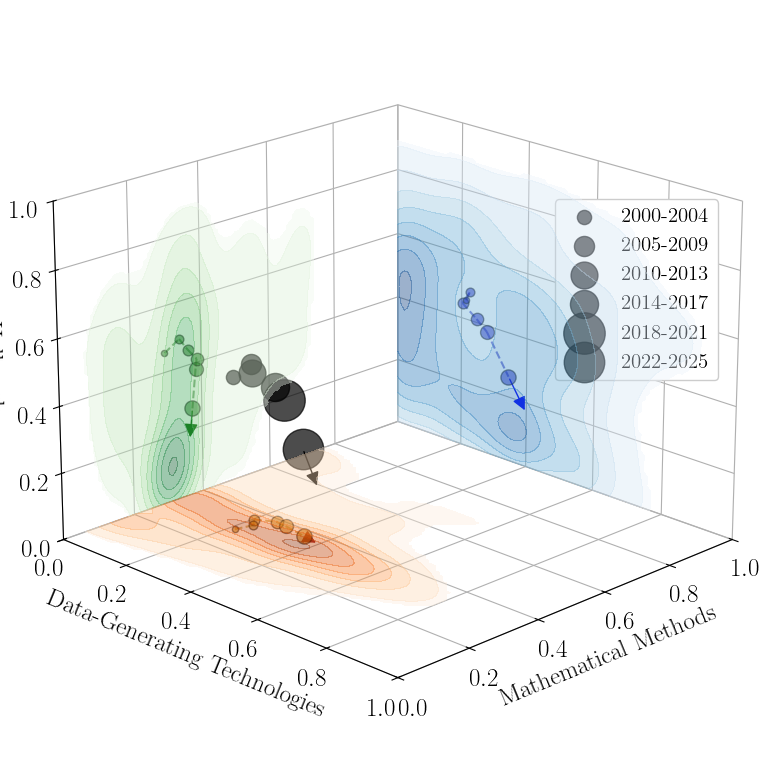

In [55]:
fig = module.plot_overall_centers_with_projections(
    dataset, overall_centers, output_dir, include_AI,
    filename_prefix='3D_Summation_of_full_dataset_with_trajectories'
)


---
---
## Crop figures

In [56]:
module.crop_output_pdfs(output_dir, include_AI, cluster_count)


Cropping 3D_Probability_Density_of_full_dataset_with_trajectories.pdf in figures...
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `3D_Probability_Density_of_full_dataset_with_trajectories.pdf'.
Cropping 3D_Summation_of_full_dataset_with_trajectories.pdf in figures...
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `3D_Summation_of_full_dataset_with_trajectories.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `3D_Probability_Density_of_Cluster_4_with_trajectories.pdf'.
Cropping 3D_Probability_Density_of_Cluster_4_with_trajectories.pdf...
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `3D_Probability_Density_of_Cluster_3_with_trajectories.pdf'.
Cropping 3D_Probability_Density_of_C